In [13]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve, confusion_matrix,accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('diabetes_dataset.csv')
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [23]:
df.drop(columns=['year','location','race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other','smoking_history'],inplace=True)
df

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
0,0,0.399399,0,0,0.202031,0.272727,0.090909,0
1,0,0.361862,0,0,0.116013,0.272727,0.045455,0
2,1,0.224224,0,0,0.160481,0.236364,0.363636,0
3,1,0.512012,0,0,0.202031,0.090909,0.359091,0
4,0,0.649650,0,0,0.160364,0.545455,0.045455,0
...,...,...,...,...,...,...,...,...
99995,0,0.411912,0,0,0.130719,0.545455,0.045455,0
99996,0,1.000000,0,0,0.311041,0.400000,0.090909,0
99997,1,0.574575,0,0,0.304739,0.490909,0.354545,0
99998,0,0.637137,0,0,0.225023,0.454545,0.340909,0


In [21]:
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])

label_mapping = dict(zip(encoder.classes_, range(len(encoder.classes_))))

print("Label Encoding Mapping:", label_mapping)


Label Encoding Mapping: {np.int64(0): 0, np.int64(1): 1}


Exploring correlation relationships between variables to understand their interactions and improve model performance.

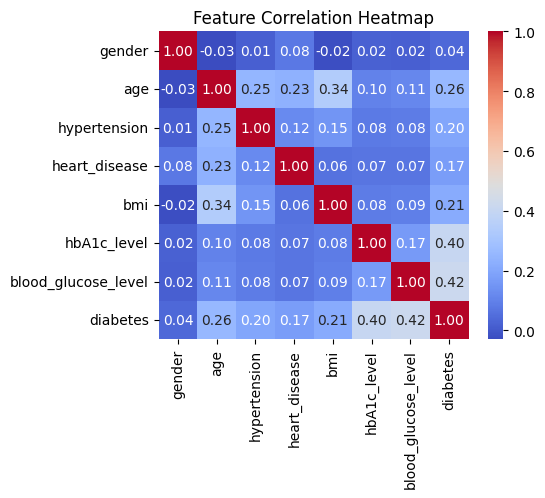

In [26]:
plt.figure(figsize=(5,4 ))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [27]:
df.drop_duplicates(inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 91295 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               91295 non-null  int64  
 1   age                  91295 non-null  float64
 2   hypertension         91295 non-null  int64  
 3   heart_disease        91295 non-null  int64  
 4   bmi                  91295 non-null  float64
 5   hbA1c_level          91295 non-null  float64
 6   blood_glucose_level  91295 non-null  float64
 7   diabetes             91295 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 6.3 MB
None


In [28]:
## removing of missing values
df = df.drop(df[df['gender'] == 2].index)
df.shape

(91295, 8)

In [29]:
# Select columns to normalize
cols_to_normalize = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

# Initialize scaler and apply normalization
scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

print(df.tail())

       gender       age  hypertension  heart_disease       bmi  hbA1c_level  \
99995       0  0.411912             0              0  0.130719     0.545455   
99996       0  1.000000             0              0  0.311041     0.400000   
99997       1  0.574575             0              0  0.304739     0.490909   
99998       0  0.637137             0              0  0.225023     0.454545   
99999       1  0.161662             0              0  0.083450     0.272727   

       blood_glucose_level  diabetes  
99995             0.045455         0  
99996             0.090909         0  
99997             0.354545         0  
99998             0.340909         0  
99999             0.045455         0  


Before: The dataset had imbalanced classes, with a higher number of negative cases (non-diabetic) compared to positive cases (diabetic).


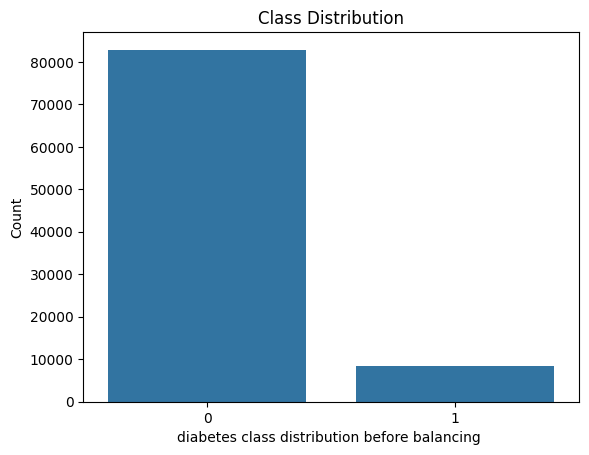

In [32]:
sns.countplot(data=df, x='diabetes')
plt.title('Class Distribution')
plt.xlabel('diabetes class distribution before balancing ')
plt.ylabel('Count')
plt.show()

SMOTE (Synthetic Minority Over-sampling Technique) was applied to balance the dataset by generating synthetic samples for the minority class.

In [42]:
from imblearn.over_sampling import SMOTE

x = df.drop(columns=['diabetes'])
y = df['diabetes']

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

# Update the original dataframe with the resampled data
df = pd.DataFrame(x_resampled, columns=x.columns)
df['diabetes'] = y_resampled

After: The dataset is now balanced, with an equal number of instances for both diabetic and non-diabetic classes, ready for model training.

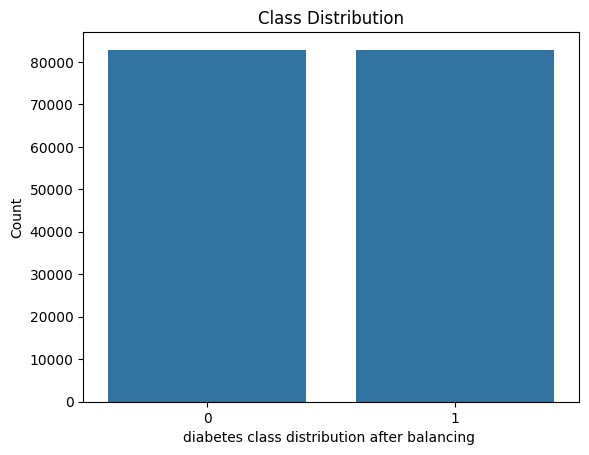

In [43]:
sns.countplot(data=df, x='diabetes')
plt.title('Class Distribution')
plt.xlabel('diabetes class distribution after balancing ')
plt.ylabel('Count')
plt.show()

In [50]:
from collections import Counter
def entropy(labels):
    """Calculate the entropy H(S)"""
    total_count = len(labels)
    counter = Counter(labels)
    ent = 0.0
    for count in counter.values():
        p = count / total_count
        ent -= p * np.log2(p)
    return ent

def conditional_entropy(X_feature, y_target):
    """Calculate the conditional entropy H(S|a)"""
    total_count = len(X_feature)
    feature_values = np.unique(X_feature)
    cond_ent = 0.0
    for value in feature_values:
        subset_y = y_target[X_feature == value]
        p = len(subset_y) / total_count
        cond_ent += p * entropy(subset_y)
    return cond_ent

def information_gain(X_feature, y_target):
    """Calculate Information Gain"""
    return entropy(y_target) - conditional_entropy(X_feature, y_target)

def split_information(X_feature):
    """Calculate the Split Information"""
    total_count = len(X_feature)
    feature_values = np.unique(X_feature)
    split_info = 0.0
    for value in feature_values:
        p = np.sum(X_feature == value) / total_count
        split_info -= p * np.log2(p)
    return split_info

def gain_ratio(X_feature, y_target):
    """Calculate the Gain Ratio"""
    ig = information_gain(X_feature, y_target)
    si = split_information(X_feature)
    if si == 0:  # to avoid division by zero
        return 0
    return ig / si


## to calculate the gain ratio for each attribute in the dataset to get the best feature we can choose
## apply it for the training dataset


print("the gain ratio for gender",gain_ratio(X_train['gender'],y_train))
print("the gain ratio for age",gain_ratio(X_train['age'],y_train))
print("the gain ratio for hypertension",gain_ratio(X_train['hypertension'],y_train))
print("the gain ratio for bmi",gain_ratio(X_train['bmi'],y_train))
print("the gain ratio for hbA1c_level",gain_ratio(X_train['hbA1c_level'],y_train))
print("the gain ratio for blood_glucose_level",gain_ratio(X_train['blood_glucose_level'],y_train))
print("the gain ratio for heart_disease",gain_ratio(X_train['heart_disease'],y_train))
gain_ratios = {
    'gender': gain_ratio(X_train['gender'], y_train),
    'age': gain_ratio(X_train['age'], y_train),
    'hypertension': gain_ratio(X_train['hypertension'], y_train),
    'bmi': gain_ratio(X_train['bmi'], y_train),
    'hbA1c_level': gain_ratio(X_train['hbA1c_level'], y_train),
    'blood_glucose_level': gain_ratio(X_train['blood_glucose_level'], y_train),
     'heart_disease': gain_ratio(X_train['heart_disease'], y_train)

}


the gain ratio for gender 0.0031142801182648568
the gain ratio for age 0.060890243565063444
the gain ratio for hypertension 0.07856782589116326
the gain ratio for bmi 0.05528563220934733
the gain ratio for hbA1c_level 0.08789815945702309
the gain ratio for blood_glucose_level 0.08626752708940849
the gain ratio for heart_disease 0.0759220485113753


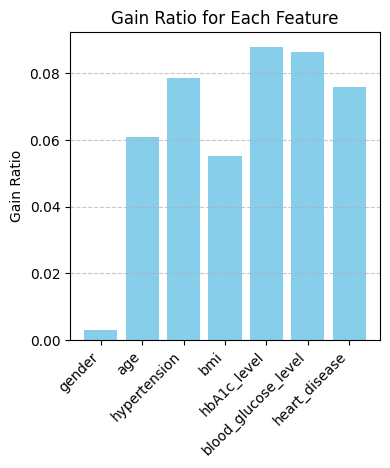

In [51]:
# Plotting the histogram
plt.figure(figsize=(4, 4))
plt.bar(gain_ratios.keys(), gain_ratios.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Gain Ratio')
plt.title('Gain Ratio for Each Feature')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [44]:
## here we will perform the interaction
# Binary feature columns
from itertools import product
df['age_high'] = (df['age'] > 60).astype(int)
df['bmi_obese'] = (df['bmi'] > 23).astype(int)
df['hba1c_diabetes'] = (df['hbA1c_level'] > 6.5).astype(int)
df['glucose_high'] = (df['blood_glucose_level'] > 126).astype(int)

binary_cols = ['age_high', 'heart_disease', 'hba1c_diabetes', 'hypertension', 'bmi_obese', 'gender', 'glucose_high']

# Interaction for hbA1c_level with all others except hbA1c_level and blood_glucose_level
for col in binary_cols:
    if col not in ['hba1c_diabetes', 'glucose_high']:
        for val1, val2 in product([0, 1], repeat=2):
            new_col = f"hbA1c_level({val1}){col}({val2})"
            df[new_col] = ((df['hba1c_diabetes'] == val1) & (df[col] == val2)).astype(int)

df['hbA1c_level(0)_glucose_high(0)'] = ((df['glucose_high'] == 0) & (df['hba1c_diabetes'] == 0)).astype(int)
df['hbA1c_level(0)_glucose_high(1)'] = ((df['glucose_high'] == 0) & (df['hba1c_diabetes'] == 1)).astype(int)
df['hbA1c_level(1)_glucose_high(0)'] = ((df['glucose_high'] == 1) & (df['hba1c_diabetes'] == 0)).astype(int)
df['hbA1c_level(1)_glucose_high(1)'] = ((df['glucose_high'] == 1) & (df['hba1c_diabetes'] == 1)).astype(int)
# Interaction for blood_glucose_level with all others except hbA1c_level and blood_glucose_level
for col in binary_cols:
    if col not in ['hba1c_diabetes', 'glucose_high']:
        for val1, val2 in product([0, 1], repeat=2):
            new_col = f"glucose_high({val1}){col}({val2})"
            df[new_col] = ((df['glucose_high'] == val1) & (df[col] == val2)).astype(int)



df.drop(columns=['age_high','bmi_obese','hba1c_diabetes','glucose_high'],inplace=True)
df

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,hbA1c_level(0)age_high(0),hbA1c_level(0)age_high(1),...,glucose_high(1)hypertension(0),glucose_high(1)hypertension(1),glucose_high(0)bmi_obese(0),glucose_high(0)bmi_obese(1),glucose_high(1)bmi_obese(0),glucose_high(1)bmi_obese(1),glucose_high(0)gender(0),glucose_high(0)gender(1),glucose_high(1)gender(0),glucose_high(1)gender(1)
0,0,0.399399,0,0,0.202031,0.272727,0.090909,0,1,0,...,0,0,1,0,0,0,1,0,0,0
1,0,0.361862,0,0,0.116013,0.272727,0.045455,0,1,0,...,0,0,1,0,0,0,1,0,0,0
2,1,0.224224,0,0,0.160481,0.236364,0.363636,0,1,0,...,0,0,1,0,0,0,0,1,0,0
3,1,0.512012,0,0,0.202031,0.090909,0.359091,0,1,0,...,0,0,1,0,0,0,0,1,0,0
4,0,0.649650,0,0,0.160364,0.545455,0.045455,0,1,0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165697,1,0.864479,0,0,0.310441,0.472727,0.276572,1,1,0,...,0,0,1,0,0,0,0,1,0,0
165698,0,0.809334,0,1,0.247049,0.424674,0.355521,1,1,0,...,0,0,1,0,0,0,1,0,0,0
165699,0,0.632443,1,0,0.173157,0.996589,0.359091,1,1,0,...,0,0,1,0,0,0,1,0,0,0
165700,0,0.838087,0,0,0.343249,0.854545,0.276742,1,1,0,...,0,0,1,0,0,0,1,0,0,0


In [45]:
from sklearn.feature_selection import mutual_info_classif
# Filter only interaction columns
interaction_cols = [col for col in df.columns if col.startswith('glucose_high(') or col.startswith('hbA1c_level(')]
y = df['diabetes']
# Compute mutual information
mi_scores = mutual_info_classif(df[interaction_cols], y, discrete_features=True)
# len(mi_scores)
mi_series = pd.Series(mi_scores, index=interaction_cols).sort_values(ascending=False)
top_features = mi_series.head(10).index

print(top_features)

Index(['hbA1c_level(0)hypertension(0)', 'hbA1c_level(0)hypertension(1)',
       'glucose_high(0)hypertension(1)', 'glucose_high(0)hypertension(0)',
       'glucose_high(0)heart_disease(0)', 'glucose_high(0)heart_disease(1)',
       'hbA1c_level(0)heart_disease(1)', 'hbA1c_level(0)heart_disease(0)',
       'glucose_high(0)gender(0)', 'glucose_high(0)gender(1)'],
      dtype='object')


In [46]:
df.drop(columns=[col for col in df.columns if col in interaction_cols and col not in top_features],inplace=True)
df

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,hbA1c_level(0)heart_disease(0),hbA1c_level(0)heart_disease(1),hbA1c_level(0)hypertension(0),hbA1c_level(0)hypertension(1),glucose_high(0)heart_disease(0),glucose_high(0)heart_disease(1),glucose_high(0)hypertension(0),glucose_high(0)hypertension(1),glucose_high(0)gender(0),glucose_high(0)gender(1)
0,0,0.399399,0,0,0.202031,0.272727,0.090909,0,1,0,1,0,1,0,1,0,1,0
1,0,0.361862,0,0,0.116013,0.272727,0.045455,0,1,0,1,0,1,0,1,0,1,0
2,1,0.224224,0,0,0.160481,0.236364,0.363636,0,1,0,1,0,1,0,1,0,0,1
3,1,0.512012,0,0,0.202031,0.090909,0.359091,0,1,0,1,0,1,0,1,0,0,1
4,0,0.649650,0,0,0.160364,0.545455,0.045455,0,1,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165697,1,0.864479,0,0,0.310441,0.472727,0.276572,1,1,0,1,0,1,0,1,0,0,1
165698,0,0.809334,0,1,0.247049,0.424674,0.355521,1,0,1,1,0,0,1,1,0,1,0
165699,0,0.632443,1,0,0.173157,0.996589,0.359091,1,1,0,0,1,1,0,0,1,1,0
165700,0,0.838087,0,0,0.343249,0.854545,0.276742,1,1,0,1,0,1,0,1,0,1,0


In [47]:
x=df.drop(columns=['diabetes'])
y=df['diabetes']
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [59]:
# Create a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [60]:
 ## accuracy, precision, recall, and the F1-score.
y_pred = rf.predict(X_test)

In [61]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[15964,   511],
       [  397, 16269]])

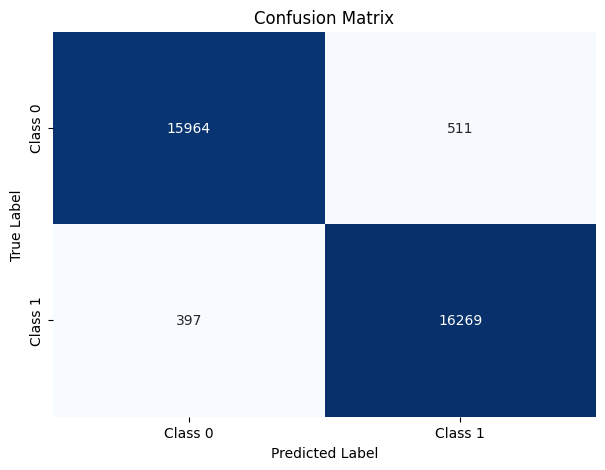

In [62]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

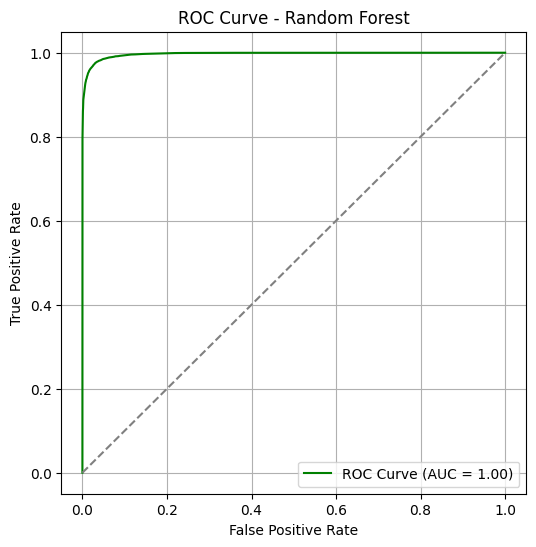

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Train the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict probabilities for the positive class
y_pred_prob = rf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='green', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


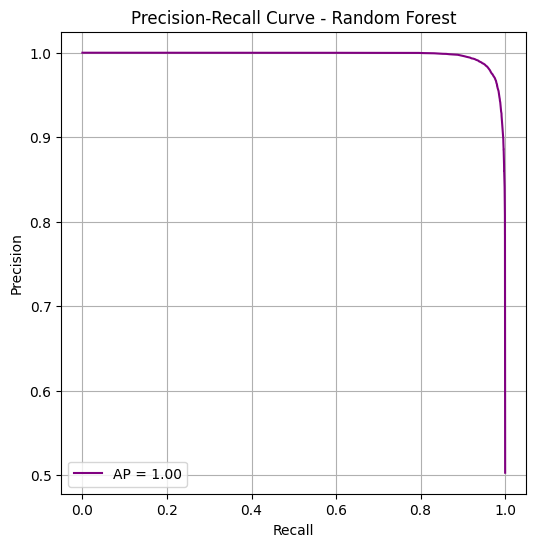

In [65]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
y_pred_prob = rf.predict_proba(X_test)[:, 1]

# Compute precision-recall curve and average precision
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)

# Plot Precision-Recall curve
plt.figure(figsize=(6, 6))
plt.plot(recall, precision, color='purple', label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


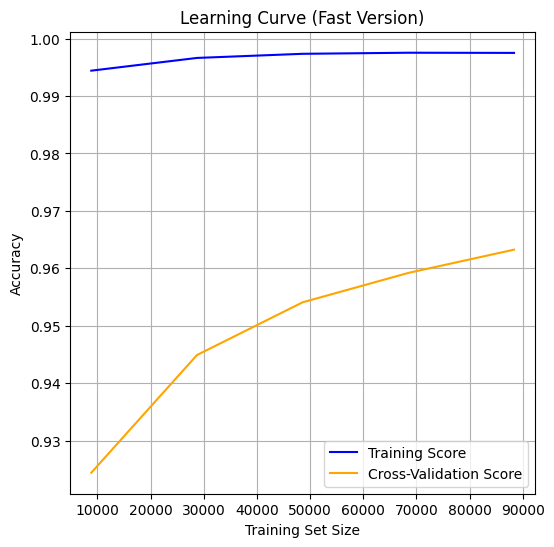

In [68]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Use a lighter model for quicker execution
rf = RandomForestClassifier(n_estimators=10, random_state=42)

# Generate learning curve data (fewer points and CV folds)
train_sizes, train_scores, test_scores = learning_curve(
    rf, X_train, y_train, cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Compute means
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Score', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-Validation Score', color='orange')
plt.title('Learning Curve (Fast Version)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [69]:
accuracy=accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9726019130382306
Precision: 0.9695470798569726
Recall: 0.9761790471618865
F1-score: 0.9728517610476589
